In [1]:
import pydotplus
from IPython.display import Image,display,Audio
from gtts import gTTS
import matplotlib.pyplot as plt
import pytesseract
import cv2
from requests import get
import os
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Images_Vision")

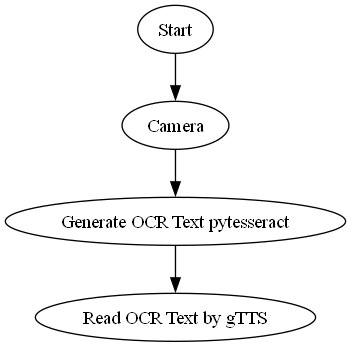

In [ ]:
myplan = """
digraph G {
    Start -> Camera
    Camera -> "Generate OCR Text pytesseract"
    "Generate OCR Text pytesseract" -> "Read OCR Text by gTTS"
}
"""
mygraph=pydotplus.graph_from_dot_data(myplan)
mygraph.write_png("mygraph.png")
display(Image(filename="mygraph.png"))

In [ ]:
import shutil
def download_file(url,filename):
    with open(filename,"wb") as file:
        response=get(url)
        file.write(response.content)
download_file("https://github.com/tesseract-ocr/tessdata/blob/main/ara.traineddata","model_arabic")
source=r"C:\Users\DT1\Desktop\proj-python\Images_Vision\model_arabic"
destination=r"C:\Users\DT1\Desktop\proj-python\models"
shutil.move(source, destination)
print("Model downloaded and moved successfully")

Model downloaded and moved successfully


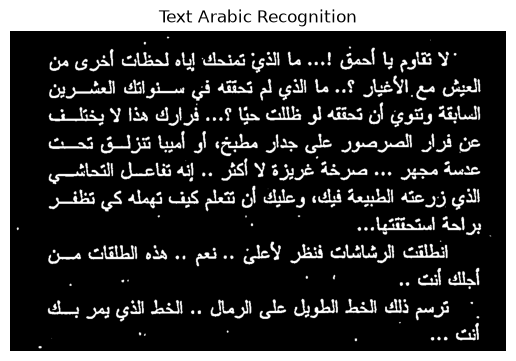

'لا تقاوم يا أحمق !... ما الذي تمنحك إياه لحظات أخرى من
العيش مع الأغيار ؟.. ما الذي لم تحققه ني سنوائك العشرين
السابقة وتنوي أن تحققه لو ظللت حيا ؟. .. فرارك هذا لا يختكدف
عن فرار الصرصور على جدار مطبخ؛ أو أميبا تنزلق تحت
عدسة مجير . .. صرخة غريزة لا أكثر .. إنه تفاعسل التحاشي
الذي زرعته الطبيعة فيك» وعليك أن تتعلم كيف تهمله كي تظفر
. براحة استحتقتها...

الطلقت الرشائئات فنظر لأعلن ‎٠٠‏ تعم . .. هذه الطلقات مسن
أجلك أنت ..
ترسم ذلك الخط الطويل على الرمال .. الخط الذي يمر بك



In [ ]:
model_path=r"C:\Program Files\Tesseract-OCR\tesseract.exe"
pytesseract.pytesseract.tesseract_cmd=model_path
img=cv2.imread("text_arabic.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
h,w=img.shape[:2]
img=cv2.resize(img,(w*2,h*2))
hImg,wImg=img.shape[:2]
img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_blur=cv2.GaussianBlur(img_gray,(3,3),0)
thresh=cv2.adaptiveThreshold(img_blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,25,8)
plt.imshow(thresh,cmap="gray")
plt.axis("off")
plt.title("Text Arabic Recognition")
plt.show()
text=pytesseract.image_to_string(thresh,lang="ara")
print(text)

In [ ]:
tts=gTTS(text=text,lang="ar")
tts.save("text_arabic.mp3")
source=r"C:\Users\DT1\Desktop\proj-python\Images_Vision\text_arabic.mp3"
destination=r"C:\Users\DT1\Desktop\proj-python\music"
shutil.move(source,destination)
print("Audio file saved successfully!")

Audio file saved successfully!


In [ ]:
audio_path=r"C:\Users\DT1\Desktop\proj-python\music\text_arabic.mp3"
Audio(audio_path,autoplay=True)